In [1]:
from simbanator.io.simba import Simulation
from simbanator.analysis.particles import extract_particles

# Load your simulation (use the name you configured)
sim = Simulation("test_sim")  # Replace XX with your snapshot number

# Load the Caesar catalog for this snapshot
obj = sim.load_catalog(136)
snap_path = sim.get_snapshot_file(136)

yt : [INFO     ] 2026-03-11 18:15:09,079 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_135.hdf5
yt : [INFO     ] 2026-03-11 18:15:09,095 Found 486206 halos
yt : [INFO     ] 2026-03-11 18:15:09,098 Found 48895 galaxies


In [2]:
# Find the central galaxy of the most massive halo
halos = obj.halos
most_massive_halo = max(halos, key=lambda h: h.masses['total'])
central_gal_id = [i.GroupID for i in obj.galaxies if i.central==1 and i.GroupID in most_massive_halo.galaxy_index_list][0]
central_gal = [g for g in obj.galaxies if g.GroupID == central_gal_id][0]
print(f"Central galaxy GroupID: {central_gal.GroupID}")

Central galaxy GroupID: 0


In [2]:
# Filter star/gas particles belonging to the central galaxy
filtered = extract_particles(obj, snap_path, snap=136, galaxy_id=0)

Reading snapshot: /media/lorenzong/Data1/SIMBA_catalogs/snap_m100n1024_136.hdf5


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/media/lorenzong/Data1/SIMBA_catalogs/snap_m100n1024_136.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

yt : [INFO     ] 2026-03-08 18:10:58,016 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 18:10:58,022 Calculating time from 7.894e-01 to be 3.366e+17 seconds
yt : [INFO     ] 2026-03-08 18:10:58,023 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 18:10:58,063 Parameters: current_time              = 3.3658961265260954e+17 s
yt : [INFO     ] 2026-03-08 18:10:58,063 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 18:10:58,064 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 18:10:58,064 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 18:10:58,064 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 18:10:58,064 Parameters: current_redshift          = 0.266842677597781
yt : [INFO     ] 2026-03-08 18:10:58,064 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 18:10:58,065 Paramet

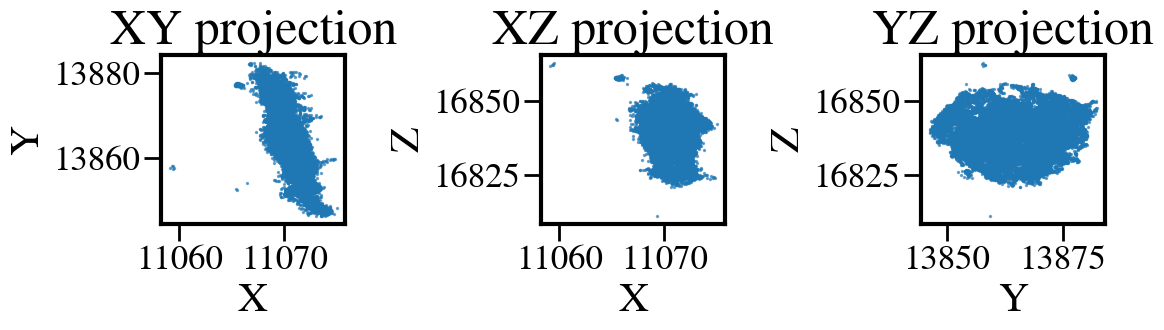

In [4]:
from simbanator.visualization.rendering import ParticleProjectionRender
proj = ParticleProjectionRender(snap_path, sim.get_caesar_file(snap=136), central_gal_id, particle_type='PartType0')
proj.plot()

yt : [INFO     ] 2026-03-08 18:14:27,697 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 18:14:27,701 Calculating time from 7.894e-01 to be 3.366e+17 seconds
yt : [INFO     ] 2026-03-08 18:14:27,701 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 18:14:27,755 Parameters: current_time              = 3.3658961265260954e+17 s
yt : [INFO     ] 2026-03-08 18:14:27,756 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 18:14:27,756 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 18:14:27,756 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 18:14:27,757 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 18:14:27,757 Parameters: current_redshift          = 0.266842677597781
yt : [INFO     ] 2026-03-08 18:14:27,757 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 18:14:27,757 Paramet

center=======================> [14024.223 17562.467 21336.305]
[[14028.31164787 17549.62304015 21329.05913491]
 [14028.66307084 17549.45186316 21328.48778919]
 [14025.46285461 17544.93211037 21342.93467393]
 ...
 [14023.66946386 17567.88003001 21315.62117417]
 [14023.89052024 17567.79614194 21315.81388999]
 [14023.86217968 17567.77460312 21315.84563142]]


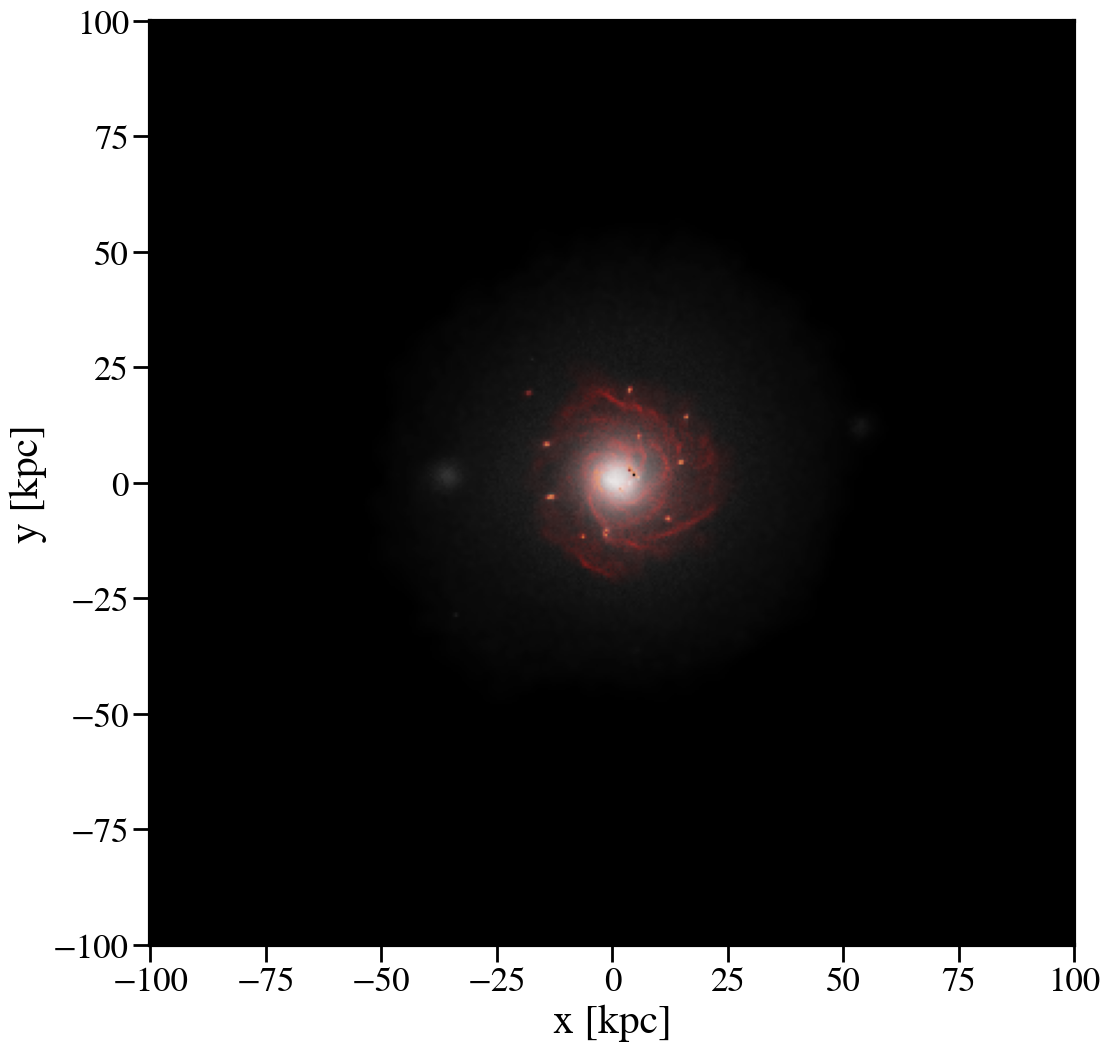

In [4]:
# Render an RGB image of the central galaxy using the RenderRGB module
from simbanator.visualization.rendering import RenderRGB

# Use existing notebook variables
snapfile = snap_path  # Path to snapshot file
gal_id = int(central_gal_id)  # Galaxy index
catfile = sim.get_caesar_file(snap=136)  # Path to Caesar catalog
propr = ('Masses', 'Masses', 'Masses')  # Properties for gas, stars, dust

# Instantiate the renderer
renderer = RenderRGB(snapfile, catfile, gal_id, propr, region=False, ifdust=True)

# Set up the camera (optional: adjust extent/xsize/ysize as needed)
camera = renderer.set_camera(extent=100, xsize=400, ysize=400)

# Generate the RGB image
image = renderer.generate_images(camera, vmin=1, vmax=100)
# Plot and save the image
renderer.plot(image, 'x [kpc]', 'y [kpc]', f'central_gal_{gal_id}')